In [1]:
from pathlib import Path as p
from IPython.display import display

import pandas as pd

In [2]:
def list_files(dir):
    for item in sorted(dir.iterdir()):
        item_type = 'folder' if item.is_dir() else 'file'
        print(f"- [{item_type}] {item.name}")

curr_dir = p.cwd()

print(f"Current working directory: {curr_dir}")
print("\n Files and Folders found: ")

list_files(curr_dir)

Current working directory: C:\Users\chari\Desktop\airqo_cole_charis_assgnmnt

 Files and Folders found: 
- [folder] .git
- [folder] .idea
- [file] AI Model Deployment and Scalability Assignment 4.pdf
- [file] Assignment 4 - AirQo PM2.5 Prediction.pdf
- [file] requirements.txt
- [file] Sensor Data Jan - July 2026.csv
- [file] train.ipynb


In [3]:
data_file = p('Sensor Data Jan - July 2026.csv')
data = pd.read_csv(data_file)

In [4]:
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")
print(f"Column Names: {data.columns.tolist()}")
print()

Rows: 14600
Columns: 12
Column Names: ['site_name', 'datetime', 'frequency', 'network', 'latitude', 'longitude', 'temperature', 'humidity', 'pm2_5_calibrated_value', 'pm10_calibrated_value', 'site_id', 'device_name']



In [5]:
print("Data Types; ")
print(data.dtypes)

Data Types; 
site_name                  object
datetime                   object
frequency                  object
network                    object
latitude                  float64
longitude                 float64
temperature               float64
humidity                  float64
pm2_5_calibrated_value    float64
pm10_calibrated_value     float64
site_id                    object
device_name                object
dtype: object


In [6]:
measurement_columns = [
    'latitude',
    'longitude',
    'temperature',
    'humidity',
    'pm2_5_calibrated_value',
    'pm10_calibrated_value'
]

In [7]:
missing_values = pd.DataFrame({
    'null_values' : data[measurement_columns].isna().sum(),
    'zero_values' : (data[measurement_columns]==0).sum()
})

missing_values['total_missing'] = (
    missing_values['null_values'] + missing_values['zero_values']
)

print("Missing values; ")
display(missing_values)

Missing values; 


,null_values,zero_values,total_missing
latitude,1,3085,3086
longitude,0,3067,3067
temperature,54,4066,4120
humidity,206,4159,4365
pm2_5_calibrated_value,325,0,325
pm10_calibrated_value,427,3,430


In [8]:
print("First five rows; ")
display(data.head())

First five rows; 


,site_name,datetime,frequency,network,latitude,longitude,temperature,humidity,pm2_5_calibrated_value,pm10_calibrated_value,site_id,device_name
0,Salama Road,2026-01-01 00:00:00Z,hourly,airgradient,0.33354,32.56861,20.535000,88.405000,181.16,197.89,694140834973ef0013d1a9b0,ag_588c81267534
1,Salama Road,2026-01-01 01:00:00Z,hourly,airgradient,0.33354,32.56861,20.640000,89.610000,290.98,318.91,694140834973ef0013d1a9b0,ag_588c81267534
2,Salama Road,2026-01-01 02:00:00Z,hourly,airgradient,0.33354,32.56861,20.821053,89.610526,274.59,301.09,694140834973ef0013d1a9b0,ag_588c81267534
3,Salama Road,2026-01-01 03:00:00Z,hourly,airgradient,0.33354,32.56861,20.605000,90.055000,242.30,264.05,694140834973ef0013d1a9b0,ag_588c81267534
4,Salama Road,2026-01-01 04:00:00Z,hourly,airgradient,0.33354,32.56861,20.675000,88.715000,206.34,225.85,694140834973ef0013d1a9b0,ag_588c81267534


In [9]:
print("Unique values in categorical columns; ")
for column in ['frequency', 'network', 'site_name', 'device_name']:
    print("\n Column: ")
    print(data[column].unique())

Unique values in categorical columns; 

 Column: 
['hourly']

 Column: 
['airgradient' 'airqo']

 Column: 
['Salama Road' 'Mbarara Central' 'Rakai Health Sciences Program Facility'
 'Mbarara University, Mbarara' 'Kawanda 2' 'Gulu Main Market'
 'kawempe moslem p/s' 'Civic Centre, Kampala Central'
 'Nsasa, Kira Municipality' 'Embassy of France, Lumumba avenue'
 'Kisenyi Health Centre 4 (KCCA)' 'Lorry Park, Fort Portal'
 'Kawaala Health Centre' 'Buganda Road P.S' 'Nile avenue, Kampla, Uganda'
 'Kiswa Health Centre' 'Komamboga Health Centre'
 'Agricultural Resource Centre Kyanja' 'Kamwokya Primary School'
 'Kawempe Division' 'Kololo AirStrip'
 'Makerere University Weather Station 94' 'Nakawa Division KCCA'
 'KCCA Hall,Parliamentary Avenue' 'St Paul Demonstration School,Ggaba'
 'Kololo Mabua Stores' 'Kitebi Health Centre 3,Kabusu road'
 'KCCA Division Kisungu' 'KCCA Stadium Lugogo' 'Namungona Primary school'
 'Kira Road Police, Kira road, Kampala Uganda' 'Bakuli, Kampala, Uganda'
 'Ministry

In [10]:
print(f"Datetime samples: {data['datetime'].head(10).tolist()}")

Datetime samples: ['2026-01-01 00:00:00Z', '2026-01-01 01:00:00Z', '2026-01-01 02:00:00Z', '2026-01-01 03:00:00Z', '2026-01-01 04:00:00Z', '2026-01-01 05:00:00Z', '2026-01-01 06:00:00Z', '2026-01-01 07:00:00Z', '2026-01-01 08:00:00Z', '2026-01-01 09:00:00Z']


In [11]:
print("Numeric description; ")
display(data.describe().T)

Numeric description; 


,count,mean,std,min,25%,50%,75%,max
latitude,14599.0,0.265731,0.680336,-1.2726,0.00000,0.313564,0.351635,2.829097
longitude,14600.0,25.272042,13.158312,0.0000,30.25565,32.552280,32.591359,33.235100
temperature,14546.0,17.295417,11.326213,0.0000,0.00000,21.600000,25.508334,44.510000
humidity,14394.0,56.100501,37.608918,0.0000,0.00000,72.720834,86.264464,99.000000
pm2_5_calibrated_value,14275.0,32.706103,30.364417,4.2900,13.25500,20.840000,44.975000,998.400000
pm10_calibrated_value,14173.0,45.079282,45.226573,0.0000,14.56000,33.890000,59.840000,802.100000


In [12]:
datetime_parsed = pd.to_datetime(['datetime'], errors='coerce')

print("Invalid datetime values; ")
print(datetime_parsed.isna().sum())

print("\n Datetime range; ")
print(f"Earliest: {datetime_parsed.min()}")
print(f"Latest: {datetime_parsed.max()}")

Invalid datetime values; 
1

 Datetime range; 
Earliest: NaT
Latest: NaT


In [13]:
print("Duplicate rows; ")
print(data.duplicated().sum())

Duplicate rows; 
0


In [14]:
print("Rows with missing pm2.5 target; ")

pm2_5 = ['pm2_5_calibrated_value']
missing_pm2_5 = pd.DataFrame({
    'null_values' : data[pm2_5].isna().sum(),
    'zero_values' : (data[pm2_5]==0).sum()
})

missing_pm2_5['total_missing'] = (
    missing_pm2_5['null_values'] + missing_pm2_5['zero_values']
)

display(missing_pm2_5)

Rows with missing pm2.5 target; 


,null_values,zero_values,total_missing
pm2_5_calibrated_value,325,0,325


In [15]:
clean_data = data.copy()

In [16]:
clean_data[measurement_columns] = (clean_data[measurement_columns].replace(0, pd.NA))
clean_data['datetime'] = pd.to_datetime(clean_data['datetime'], format='ISO8601', errors='coerce', utc=True)

In [17]:
print(f"Data shape: {clean_data.shape}")

Data shape: (14600, 12)


In [18]:
print("Invalid datetime values: ")
print(clean_data['datetime'].isna().sum())

print("\n Datetime range; ")
print(f"Earliest: {clean_data['datetime'].min()}")
print(f"Latest: {clean_data['datetime'].max()}")

Invalid datetime values: 
0

 Datetime range; 
Earliest: 2026-01-01 00:00:00+00:00
Latest: 2026-06-03 03:00:00+00:00


In [19]:
print("Missing values after cleaning zeros: ")
print(clean_data.isna().sum())

Missing values after cleaning zeros: 
site_name                    0
datetime                     0
frequency                    0
network                      0
latitude                  3086
longitude                 3067
temperature               4120
humidity                  4365
pm2_5_calibrated_value     325
pm10_calibrated_value      430
site_id                   7508
device_name                  0
dtype: int64


### Sensor Identifiers

- Uniquely identify sensors relative to their locations, to see how many unique sensor each location has

In [20]:
print("Sensor-level coverage using device_name; ")
sensor_coverage = (clean_data.groupby('device_name', dropna=False).agg(first_timestamp=('datetime', 'min'), last_timestamp=('datetime', 'max'), records=('datetime', 'count'), unique_sites=('site_name', 'nunique'), unique_site_ids=('site_id', 'nunique')).sort_values('records'))

display(sensor_coverage.head(10))

Sensor-level coverage using device_name; 


,first_timestamp,last_timestamp,records,unique_sites,unique_site_ids
device_name,,,,,
ag_588c81266dc8,2026-04-01 05:00:00+00:00,2026-06-02 11:00:00+00:00,20,1,0
airqo_g5367,2026-01-01 07:00:00+00:00,2026-01-02 15:00:00+00:00,21,1,1
airqo_g5339,2026-01-01 00:00:00+00:00,2026-06-02 00:00:00+00:00,23,1,1
aq_04,2026-06-01 06:00:00+00:00,2026-06-02 18:00:00+00:00,27,1,1
aq_48,2026-04-01 16:00:00+00:00,2026-04-02 21:00:00+00:00,30,1,0
airqo_g5564,2026-01-01 00:00:00+00:00,2026-06-02 11:00:00+00:00,33,1,0
airqo_g5204,2026-01-01 07:00:00+00:00,2026-06-02 11:00:00+00:00,34,1,1
airqo_g5305,2026-01-01 07:00:00+00:00,2026-01-02 23:00:00+00:00,37,1,1
aq_27,2026-01-01 00:00:00+00:00,2026-01-02 23:00:00+00:00,39,1,0


### Sensor-Hour uniqueness and coverage

- Check if each device has less/more than one record per hour and hence summarize the amount of data available per device

In [21]:
sensor_hour_duplicates = (
    clean_data.groupby(['device_name', 'datetime'], dropna=False).size().reset_index(name='rows_per_sensor_hour')
)

duplicate_sensor_hours = sensor_hour_duplicates[
    sensor_hour_duplicates['rows_per_sensor_hour'] > 1
]

print("Duplicate sensor-hour combinations:")
print(f"Number of duplicated sensor-hour combinations: {len(duplicate_sensor_hours)}")
print(
    f"Extra rows caused by duplicates: "
    f"{duplicate_sensor_hours['rows_per_sensor_hour'].sub(1).sum()}"
)

print("\n Records per device; ")
records_per_device = (
    clean_data.groupby('device_name', dropna=False).size().rename('records')
)

print(records_per_device.describe())

print("\n Devices with the most records: ")
print(records_per_device.sort_values(ascending=False).head(10))

print("\n Devices with the fewest records: ")
print(records_per_device.sort_values().head(10))

print("\n Sites associated with more than one device: ")
devices_per_site = (
    clean_data.groupby('site_name', dropna=False)['device_name'].nunique().sort_values(ascending=False)
)

print(devices_per_site[devices_per_site > 1 ])

Duplicate sensor-hour combinations:
Number of duplicated sensor-hour combinations: 0
Extra rows caused by duplicates: 0

 Records per device; 
count    149.000000
mean      97.986577
std       39.608385
min       20.000000
25%       58.000000
50%      105.000000
75%      137.000000
max      147.000000
Name: records, dtype: float64

 Devices with the most records: 
device_name
airqo-g5184    147
airqo_g5282    147
aq_66          147
aq_g5_37       147
aq_g519        147
airqo_g5247    146
aq_g535        145
aq_58          145
aq_g517        145
aq_47          145
Name: records, dtype: int64

 Devices with the fewest records: 
device_name
ag_588c81266dc8    20
airqo_g5367        21
airqo_g5339        23
aq_04              27
aq_48              30
airqo_g5564        33
airqo_g5204        34
airqo_g5305        37
aq_27              39
airqo_g5566        40
Name: records, dtype: int64

 Sites associated with more than one device: 
site_name
Makerere University Weather Station 94    3
Civic 

- No duplicate sensor-hour combinations, so, device-name and datetime can be used to identify an individual observation
- Sensor coverage is highly uneven, some having up to 147 records and others having only 20 records
- Multiple devices can belong to one site (hence site_name can't be a sensor identifier)

### Time gaps between consecutive observations for each sensor

In [22]:
sorted_data = clean_data.sort_values(
    ['device_name', 'datetime']
).copy()

sorted_data['time_since_previous_reading'] = (
    sorted_data.groupby('device_name')['datetime'].diff()
)

gap_summary = (
    sorted_data.dropna(subset=['time_since_previous_reading'])['time_since_previous_reading'].value_counts().sort_index()
)

print("Most common time gaps between consecutive readings; ")
print(gap_summary.head(20))

print("\n Time-gap description: ")
print(
    sorted_data['time_since_previous_reading'].dropna().describe()
)

print("\n Number of gaps longer than one hour; ")
long_gaps = sorted_data[
    sorted_data['time_since_previous_reading'] > pd.Timedelta(hours=1)
]

print(len(long_gaps))

print("\n Largest observed gaps: ")
display(
    long_gaps[
        ['device_name', 'datetime', 'time_since_previous_reading']
    ].sort_values('time_since_previous_reading', ascending=False).head(20)
)

Most common time gaps between consecutive readings; 
time_since_previous_reading
0 days 01:00:00    13668
0 days 02:00:00      236
0 days 03:00:00      125
0 days 04:00:00       43
0 days 05:00:00       44
0 days 06:00:00       25
0 days 07:00:00       19
0 days 08:00:00       14
0 days 09:00:00        7
0 days 10:00:00        5
0 days 11:00:00        1
0 days 12:00:00        4
0 days 13:00:00        7
0 days 14:00:00        3
0 days 15:00:00        3
0 days 16:00:00        3
0 days 17:00:00        6
0 days 18:00:00        5
0 days 19:00:00        2
0 days 20:00:00        4
Name: count, dtype: int64

 Time-gap description: 
count                        14451
mean     1 days 04:38:53.734689640
std      9 days 08:28:41.013483450
min                0 days 01:00:00
25%                0 days 01:00:00
50%                0 days 01:00:00
75%                0 days 01:00:00
max              150 days 19:00:00
Name: time_since_previous_reading, dtype: object

 Number of gaps longer than one hour; 

,device_name,datetime,time_since_previous_reading
12732,aq_g4_99,2026-06-02 19:00:00+00:00,150 days 19:00:00
5347,airqo-g5186,2026-04-01 05:00:00+00:00,89 days 20:00:00
8140,aq_g513,2026-04-01 00:00:00+00:00,89 days 15:00:00
6004,airqo_g5342,2026-04-01 06:00:00+00:00,89 days 12:00:00
5429,airqo_g5206,2026-04-02 09:00:00+00:00,89 days 09:00:00
9497,aq_g5_86,2026-04-02 06:00:00+00:00,89 days 08:00:00
6370,airqo_g5375,2026-04-01 00:00:00+00:00,88 days 22:00:00
6919,airqo_g5564,2026-04-01 04:00:00+00:00,88 days 18:00:00
5416,airqo_g5204,2026-04-01 06:00:00+00:00,88 days 17:00:00
8416,aq_g522,2026-04-01 15:00:00+00:00,88 days 15:00:00


- This gives us some insight on the gaps for offline time periods
- Helps us decide where to interpolate and where not to
- short gaps: potentially eligible for interpolation
- long gaps: retained as missing to represent sensor downtime

## Data Preparation Pipeline

Following the team's approach report (Section 1):

**Step 1 — Data types and null standardization.** A value of `0` or empty is treated as missing (not a genuine reading) for `temperature`, `humidity`, `pm2_5_calibrated_value`, `pm10_calibrated_value`, `latitude`, and `longitude` — already applied above via `clean_data`. This step formalizes it and enforces consistent dtypes: `datetime` as UTC datetime, measurement fields as `float64`, and identifiers (`site_id`, `site_name`, `device_name`) as pandas `string`.

Note: `site_id` is missing in ~51% of rows, while `device_name` is fully populated and 1:1 with individual sensors (confirmed above — no duplicate sensor-hour combinations). `device_name` is therefore used as the canonical sensor identifier for grouping/resampling; `site_id` is kept as a passthrough categorical field but not relied on for imputation or grouping.</cell_id>

In [23]:
identifier_columns = ['site_id', 'site_name', 'device_name']

# Measurement fields must be numeric floats; identifiers consistent strings.
# Nullable 'Float64' (not numpy 'float64') is required here since the columns
# already contain pd.NA from the zero -> null replacement above.
clean_data[measurement_columns] = clean_data[measurement_columns].astype('Float64')
clean_data[identifier_columns] = clean_data[identifier_columns].astype('string')

print("Dtypes after enforcement; ")
print(clean_data.dtypes)

Dtypes after enforcement; 
site_name                      string[python]
datetime                  datetime64[ns, UTC]
frequency                              object
network                                object
latitude                              Float64
longitude                             Float64
temperature                           Float64
humidity                              Float64
pm2_5_calibrated_value                Float64
pm10_calibrated_value                 Float64
site_id                        string[python]
device_name                    string[python]
dtype: object


In [24]:
print("Validation summary after Step 1 (types + null standardization); ")

validation_summary = pd.DataFrame({
    'dtype': clean_data.dtypes.astype(str),
    'null_count': clean_data.isna().sum(),
    'zero_count': (clean_data[measurement_columns] == 0).reindex(clean_data.columns, axis=1).sum(),
})

display(validation_summary)

print(f"\n Rows: {clean_data.shape[0]}, Columns: {clean_data.shape[1]}")
print(f"Remaining zero values in measurement columns (should be 0): "
      f"{(clean_data[measurement_columns] == 0).sum().sum()}")

Validation summary after Step 1 (types + null standardization); 


,dtype,null_count,zero_count
site_name,string,0,0.0
datetime,"datetime64[ns, UTC]",0,0.0
frequency,object,0,0.0
network,object,0,0.0
latitude,Float64,3086,0.0
longitude,Float64,3067,0.0
temperature,Float64,4120,0.0
humidity,Float64,4365,0.0
pm2_5_calibrated_value,Float64,325,0.0
pm10_calibrated_value,Float64,430,0.0



 Rows: 14600, Columns: 12
Remaining zero values in measurement columns (should be 0): 0


**Step 2 — Latitude/longitude imputation (Section 1.4).** Missing coordinates are filled with the median latitude/longitude of the sensor's own `site_name`, since coordinates are a site-level (not time-varying) property and median is outlier-resistant to the occasional bad GPS fix.

Six sensors (`airqo_g5367`, `aq_43`, `aq_54`, `aq_79`, `aq_g518`, `aq_g5_50`) have **no valid coordinate reading at all** across their entire history, so there is no within-site median to fall back on — the per-site median leaves these six as `NaN`. They are handled separately in **Step 2b** immediately below via KNN imputation, rather than left missing.

In [25]:
coordinate_columns = ['latitude', 'longitude']

site_median_coords = (
    clean_data.groupby('site_name')[coordinate_columns].median()
)

sites_without_any_valid_coords = site_median_coords[
    site_median_coords.isna().any(axis=1)
].index.tolist()

print(f"Sites with no valid coordinate at all (left as NaN): {len(sites_without_any_valid_coords)}")
print(sites_without_any_valid_coords)

for column in coordinate_columns:
    lookup = site_median_coords[column]
    imputed = clean_data['site_name'].map(lookup)
    clean_data[column] = clean_data[column].fillna(imputed)

Sites with no valid coordinate at all (left as NaN): 6


['Bakuli, Kampala, Uganda', 'Kalerwe, Kawempe', 'Kivubuka Budondo, Jinja', 'Makindye, Lukuli Makindye', 'Ntinda, Nakawa', 'Rushoroza Hill, Kabale']


In [26]:
print("Validation summary after Step 2 (lat/lon imputation); ")

coord_validation = pd.DataFrame({
    'null_count': clean_data[coordinate_columns].isna().sum(),
})
display(coord_validation)

print(
    f"\n Sites with remaining coordinate nulls: "
    f"{clean_data.loc[clean_data['latitude'].isna(), 'site_name'].nunique()} "
    f"(expected {len(sites_without_any_valid_coords)})"
)
print("\n Rows still missing coordinates belong only to; ")
print(
    clean_data.loc[clean_data['latitude'].isna(), 'site_name'].unique()
)

Validation summary after Step 2 (lat/lon imputation); 


,null_count
latitude,247
longitude,247



 Sites with remaining coordinate nulls: 6 (expected 6)

 Rows still missing coordinates belong only to; 
<StringArray>
[  'Bakuli, Kampala, Uganda', 'Makindye, Lukuli Makindye',
          'Kalerwe, Kawempe',            'Ntinda, Nakawa',
   'Kivubuka Budondo, Jinja',    'Rushoroza Hill, Kabale']
Length: 6, dtype: string


**Step 2b — KNN imputation for the 6 no-coordinate sites (revised).** The 6 sites left as `NaN` above never recorded a single valid latitude/longitude, so there is no within-site value to fall back on. Rather than leave them missing, `sklearn.impute.KNNImputer` is used to borrow coordinates from the sites with the *most similar pollutant/weather profile* (mean temperature, humidity, PM2.5, PM10) — a similarity-in-measurement-space proxy for "nearby," since true geographic nearest-neighbour is impossible without any coordinate to anchor these 6 sites to in the first place. Features are standardised before imputing (so PM10's ~0-800 range doesn't dominate distance over temperature's ~0-45 range) and inverse-transformed back to real units afterwards.

This is a deliberate accuracy/honesty trade-off worth stating plainly: it is **not** geographic proximity, and should be described as such in the report.

In [27]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

site_profile = clean_data.groupby('site_name').agg(
    latitude=('latitude', 'median'),
    longitude=('longitude', 'median'),
    mean_temperature=('temperature', 'mean'),
    mean_humidity=('humidity', 'mean'),
    mean_pm2_5=('pm2_5_calibrated_value', 'mean'),
    mean_pm10=('pm10_calibrated_value', 'mean'),
)

profile_columns = site_profile.columns.tolist()

scaler = StandardScaler()
scaled_profile = scaler.fit_transform(site_profile)

knn_coord_imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_scaled = knn_coord_imputer.fit_transform(scaled_profile)
imputed_profile = pd.DataFrame(
    scaler.inverse_transform(imputed_scaled),
    columns=profile_columns,
    index=site_profile.index,
)

knn_coords = imputed_profile.loc[sites_without_any_valid_coords, ['latitude', 'longitude']]
print("KNN-imputed coordinates for the 6 no-coordinate sites; ")
display(knn_coords)

for column in coordinate_columns:
    lookup = knn_coords[column]
    fill_values = clean_data['site_name'].map(lookup)
    clean_data[column] = clean_data[column].fillna(fill_values)

KNN-imputed coordinates for the 6 no-coordinate sites; 


,latitude,longitude
site_name,,
"Bakuli, Kampala, Uganda",0.060485,32.147986
"Kalerwe, Kawempe",0.335284,32.596225
"Kivubuka Budondo, Jinja",0.400398,32.911468
"Makindye, Lukuli Makindye",0.283565,32.580879
"Ntinda, Nakawa",0.187810,32.239628
"Rushoroza Hill, Kabale",0.302962,32.675632


In [28]:
print("Validation summary after Step 2b (KNN coordinate imputation); ")
print(f"Remaining latitude nulls: {clean_data['latitude'].isna().sum()} (expected 0)")
print(f"Remaining longitude nulls: {clean_data['longitude'].isna().sum()} (expected 0)")

print("\n Imputed coordinates are within Uganda's approximate bounding box "
      "(lat -1.5 to 4.2, lon 29.5 to 35.0); ")
display(
    knn_coords.assign(
        lat_in_range=knn_coords['latitude'].between(-1.5, 4.2),
        lon_in_range=knn_coords['longitude'].between(29.5, 35.0),
    )
)

Validation summary after Step 2b (KNN coordinate imputation); 
Remaining latitude nulls: 0 (expected 0)
Remaining longitude nulls: 0 (expected 0)

 Imputed coordinates are within Uganda's approximate bounding box (lat -1.5 to 4.2, lon 29.5 to 35.0); 


,latitude,longitude,lat_in_range,lon_in_range
site_name,,,,
"Bakuli, Kampala, Uganda",0.060485,32.147986,True,True
"Kalerwe, Kawempe",0.335284,32.596225,True,True
"Kivubuka Budondo, Jinja",0.400398,32.911468,True,True
"Makindye, Lukuli Makindye",0.283565,32.580879,True,True
"Ntinda, Nakawa",0.187810,32.239628,True,True
"Rushoroza Hill, Kabale",0.302962,32.675632,True,True


**Step 3 — Hourly resampling (Sections 1.3 / 7.1).** Each sensor (`device_name`) is reindexed onto a complete hourly timestamp grid spanning **2026-01-01 00:00 to 2026-07-31 23:00 UTC**, matching the window both the brief and decision doc state, so hours the device was offline appear as rows with missing measurements rather than being absent from the index entirely.

No device in the supplied CSV has any reading past **2026-06-03 03:00 UTC** (`last_observed_timestamp`, computed dynamically rather than hardcoded) — the file simply doesn't extend into July. That's kept in mind for **Step 4b**: KNN imputation is only applied up to `last_observed_timestamp`, so the July tail — which has zero ground truth anywhere in the dataset to pattern-match against — stays honestly `NaN` rather than being filled with an unfounded seasonal guess.

Static, sensor-level attributes (`site_name`, `site_id`, `network`, `frequency`, and the now-imputed `latitude`/`longitude`) are constant per `device_name` (confirmed — zero devices have more than one distinct value for any of these), so they are carried onto the newly created rows too; only the time-varying measurement fields (`temperature`, `humidity`, `pm2_5_calibrated_value`, `pm10_calibrated_value`) are genuinely missing for those hours.

In [29]:
full_hourly_index = pd.date_range(
    start='2026-01-01 00:00', end='2026-07-31 23:00', freq='h', tz='UTC', name='datetime'
)

last_observed_timestamp = clean_data['datetime'].max()

static_columns = ['site_name', 'site_id', 'network', 'frequency', 'latitude', 'longitude']
time_varying_columns = ['temperature', 'humidity', 'pm2_5_calibrated_value', 'pm10_calibrated_value']

# One static attribute row per sensor, to be broadcast onto every hour of its grid.
device_attributes = (
    clean_data.groupby('device_name', as_index=True)[static_columns]
    .first()
)

device_names = device_attributes.index

full_grid = pd.MultiIndex.from_product(
    [device_names, full_hourly_index], names=['device_name', 'datetime']
)

resampled_data = (
    clean_data
    .set_index(['device_name', 'datetime'])[time_varying_columns]
    .reindex(full_grid)
    .join(device_attributes, on='device_name')
    .reset_index()
)

resampled_data = resampled_data[
    ['device_name', 'datetime'] + static_columns + time_varying_columns
]

print(f"Resampling window: {full_hourly_index.min()} to {full_hourly_index.max()}")
print(f"Last timestamp with any real observation: {last_observed_timestamp}")
print(f"Resampled shape: {resampled_data.shape}")
print(f"Expected: {len(device_names)} devices x {len(full_hourly_index)} hours "
      f"= {len(device_names) * len(full_hourly_index)}")

Resampling window: 2026-01-01 00:00:00+00:00 to 2026-07-31 23:00:00+00:00
Last timestamp with any real observation: 2026-06-03 03:00:00+00:00
Resampled shape: (758112, 12)
Expected: 149 devices x 5088 hours = 758112


In [30]:
print("Validation summary after Step 3 (hourly resampling); ")

print(f"\n Unique devices: {resampled_data['device_name'].nunique()} (expected {len(device_names)})")
print(f"Duplicate (device, hour) rows: "
      f"{resampled_data.duplicated(subset=['device_name', 'datetime']).sum()}")

original_observations = clean_data.shape[0]
newly_created_offline_rows = resampled_data.shape[0] - original_observations
print(f"\n Original observed rows: {original_observations}")
print(f"Rows added by resampling (previously-absent offline hours): {newly_created_offline_rows}")

print("\n Static columns carried onto new rows (nulls should match Step 1/2 totals only); ")
display(resampled_data[static_columns].isna().sum())

print("\n Time-varying columns (nulls now include both originally-missing AND offline-hour rows); ")
display(resampled_data[time_varying_columns].isna().sum())

Validation summary after Step 3 (hourly resampling); 

 Unique devices: 149 (expected 149)


Duplicate (device, hour) rows: 0



 Original observed rows: 14600
Rows added by resampling (previously-absent offline hours): 743512

 Static columns carried onto new rows (nulls should match Step 1/2 totals only); 


site_name         0
site_id      366336
network           0
frequency         0
latitude          0
longitude         0
dtype: int64


 Time-varying columns (nulls now include both originally-missing AND offline-hour rows); 


temperature               747632
humidity                  747877
pm2_5_calibrated_value    743837
pm10_calibrated_value     743942
dtype: int64

**Step 4 — Offline flag and short-gap interpolation (Section 1.4).**

An explicit `is_offline` flag marks hours that were added purely by resampling (Step 3) — i.e. the sensor produced no record at all that hour, as opposed to a field being null within a real reading.

For the choice of interpolation threshold: Safarov et al. (2025, *PLOS One*, "Filling gaps in PM2.5 time series: a broad evaluation from statistical to advanced neural network models") evaluate PM2.5 gap-filling across 5–72 hour gaps and find simple interpolation performs well for short gaps but its accuracy degrades sharply beyond roughly 12–24 hours, failing to recover real peaks/troughs; Somnugpong et al. (2026, *PMC*) similarly note linear interpolation is standard practice specifically for *short*-gap imputation in air quality data. In our own gap analysis (EDA above), the overwhelming majority of real gaps between consecutive readings are 1–3 hours (≈97% of all gaps), with a long tail out to weeks/months representing genuine offline stretches.

Given both the literature's short-gap regime and our own gap distribution, **gaps of ≤ 3 consecutive missing hours are linearly interpolated**; longer gaps (including leading/trailing missing hours with no bound on one side) are left as missing, consistent with the team's principle of representing — not eliminating — real sensor downtime.

In [31]:
observed_keys = (
    clean_data[['device_name', 'datetime']]
    .drop_duplicates()
    .assign(_observed=True)
)

resampled_data = resampled_data.merge(
    observed_keys, on=['device_name', 'datetime'], how='left'
)
resampled_data['is_offline'] = resampled_data['_observed'].isna()
resampled_data = resampled_data.drop(columns='_observed')

print(f"Offline hours: {resampled_data['is_offline'].sum()} "
      f"(expected {newly_created_offline_rows})")
print(f"Observed hours: {(~resampled_data['is_offline']).sum()} "
      f"(expected {original_observations})")

Offline hours: 743512 (expected 743512)
Observed hours: 14600 (expected 14600)


In [32]:
MAX_INTERPOLATION_GAP_HOURS = 3

def interpolate_short_gaps(series, max_gap=MAX_INTERPOLATION_GAP_HOURS):
    """Linearly interpolate only interior NaN runs of length <= max_gap.

    Longer interior runs, and any leading/trailing run (no valid value on
    one side), are left untouched rather than extrapolated.
    """
    is_na = series.isna()
    run_id = (is_na != is_na.shift()).cumsum()
    run_length = is_na.groupby(run_id).transform('size')
    short_interior_mask = is_na & (run_length <= max_gap)

    interpolated = series.interpolate(method='linear', limit_area='inside')

    result = series.copy()
    result[short_interior_mask] = interpolated[short_interior_mask]
    return result


resampled_data = resampled_data.sort_values(['device_name', 'datetime']).reset_index(drop=True)

for column in time_varying_columns:
    resampled_data[f'{column}_pre_interpolation_na'] = resampled_data[column].isna()
    resampled_data[column] = (
        resampled_data.groupby('device_name')[column]
        .transform(interpolate_short_gaps)
    )

In [33]:
print("Validation summary after Step 4 (offline flag + short-gap interpolation); ")

interpolation_summary = pd.DataFrame({
    'was_missing': [resampled_data[f'{c}_pre_interpolation_na'].sum() for c in time_varying_columns],
    'still_missing': [resampled_data[c].isna().sum() for c in time_varying_columns],
}, index=time_varying_columns)
interpolation_summary['filled_by_interpolation'] = (
    interpolation_summary['was_missing'] - interpolation_summary['still_missing']
)

display(interpolation_summary)

# Sanity check: every interpolated value must sit strictly between the
# surrounding hours' min/max for that device (no wild extrapolation).
sample_device = resampled_data.loc[
    resampled_data['pm2_5_calibrated_value_pre_interpolation_na']
    & resampled_data['pm2_5_calibrated_value'].notna(),
    'device_name'
].iloc[0]

sample = resampled_data[resampled_data['device_name'] == sample_device][
    ['datetime', 'is_offline', 'pm2_5_calibrated_value_pre_interpolation_na', 'pm2_5_calibrated_value']
]
first_filled_idx = sample[
    sample['pm2_5_calibrated_value_pre_interpolation_na'] & sample['pm2_5_calibrated_value'].notna()
].index[0]
print(f"\n Example interpolated stretch for device {sample_device}; ")
display(sample.loc[first_filled_idx - 2: first_filled_idx + 3])

Validation summary after Step 4 (offline flag + short-gap interpolation); 


,was_missing,still_missing,filled_by_interpolation
temperature,747632,747056,576
humidity,747877,747292,585
pm2_5_calibrated_value,743837,743034,803
pm10_calibrated_value,743942,743098,844



 Example interpolated stretch for device ag_588c8125eca4; 


,datetime,is_offline,pm2_5_calibrated_value_pre_interpolation_na,pm2_5_calibrated_value
2163,2026-04-01 03:00:00+00:00,False,False,67.15
2164,2026-04-01 04:00:00+00:00,False,False,97.95
2165,2026-04-01 05:00:00+00:00,True,True,71.155
2166,2026-04-01 06:00:00+00:00,False,False,44.36
2167,2026-04-01 07:00:00+00:00,False,False,31.09
2168,2026-04-01 08:00:00+00:00,False,False,23.59


**Step 4b — KNN imputation for remaining gaps (revised decision).** Short-gap interpolation above only fills a small fraction of the missingness — the great majority of nulls are longer offline stretches. The team's original decision (1.1) was to leave those as genuine missing values, relying on a missing-tolerant model family; this step **reverses that call** and fills them instead, on the basis that a fitted estimate is more useful than a hard null for this pipeline. This is a deliberate deviation from the decision doc and should be described as such in the report — the `is_offline` flag and the `*_pre_interpolation_na` marker columns are kept precisely so the model can still be told "this reading is estimated, not measured," even once the raw value itself is no longer null.

`sklearn.impute.KNNImputer` is applied in two tiers, **both restricted to `datetime <= last_observed_timestamp` (2026-06-03 03:00)**: the July tail has zero real observations anywhere in the dataset to pattern-match against, so filling it would be an unfounded seasonal guess rather than gap-filling, and it is deliberately left `NaN`.

- **Tier 1 (primary, per-sensor):** for each `device_name`, the four measurement columns are imputed using that sensor's own cyclical time features (hour-of-day, day-of-week, month, sine/cosine encoded) plus the other three measurement columns — i.e. "the k most similar hours in this sensor's own history." This keeps each sensor's own offset/character intact rather than mixing it with other sensors.
- **Tier 2 (fallback, cross-sensor):** 9 sensors never recorded a single valid temperature/humidity reading (confirmed below), so Tier 1 has nothing to borrow from. For just those two columns on just those sensors, a second KNNImputer draws on *all other sensors'* readings, using latitude/longitude plus the same time features — i.e. "similar hour, at a nearby site."

In [34]:
import numpy as np

def cyclical_time_features(datetime_series):
    hour = datetime_series.dt.hour
    dow = datetime_series.dt.dayofweek
    month = datetime_series.dt.month
    return pd.DataFrame({
        'hour_sin': np.sin(2 * np.pi * hour / 24),
        'hour_cos': np.cos(2 * np.pi * hour / 24),
        'dow_sin': np.sin(2 * np.pi * dow / 7),
        'dow_cos': np.cos(2 * np.pi * dow / 7),
        'month_sin': np.sin(2 * np.pi * month / 12),
        'month_cos': np.cos(2 * np.pi * month / 12),
    }, index=datetime_series.index)


# Sensors with zero valid readings ever for a given column can't be helped by
# Tier 1 (their own history has nothing to borrow from) - identify them.
valid_counts_per_device = (
    resampled_data.groupby('device_name')[time_varying_columns]
    .apply(lambda g: g.notna().sum())
)
zero_history_devices = {
    column: valid_counts_per_device.index[valid_counts_per_device[column] == 0].tolist()
    for column in time_varying_columns
}
print("Sensors with zero valid readings ever, per column (need Tier 2 fallback); ")
for column, devices in zero_history_devices.items():
    print(f"{column}: {len(devices)} sensors")

Sensors with zero valid readings ever, per column (need Tier 2 fallback); 
temperature: 9 sensors
humidity: 9 sensors
pm2_5_calibrated_value: 0 sensors
pm10_calibrated_value: 0 sensors


In [35]:
KNN_N_NEIGHBORS = 5

def knn_impute_device_group(group):
    """KNNImputer silently drops any column that's 100% NaN within the group
    (e.g. temperature/humidity for the 9 sensors that never measured them),
    so only columns with at least one valid value are passed in; the rest
    are left untouched for Tier 2 to handle.

    Rows after last_observed_timestamp (the never-observed July tail) are
    excluded entirely - they contribute nothing as donors, and must not be
    filled as targets either."""
    result = group[time_varying_columns].copy()

    eligible = group[group['datetime'] <= last_observed_timestamp]
    features = cyclical_time_features(eligible['datetime'])
    imputable_columns = [c for c in time_varying_columns if eligible[c].notna().any()]

    if imputable_columns:
        matrix = pd.concat([features, eligible[imputable_columns]], axis=1)
        imputer = KNNImputer(n_neighbors=KNN_N_NEIGHBORS)
        filled = imputer.fit_transform(matrix)
        filled_df = pd.DataFrame(filled, columns=matrix.columns, index=eligible.index)
        result.loc[eligible.index, imputable_columns] = filled_df[imputable_columns]
    return result


resampled_data = resampled_data.sort_values(['device_name', 'datetime']).reset_index(drop=True)

tier1_parts = [
    knn_impute_device_group(group)
    for _, group in resampled_data.groupby('device_name', sort=False)
]
tier1_filled = pd.concat(tier1_parts).sort_index()
resampled_data[time_varying_columns] = tier1_filled

print("Remaining nulls after Tier 1 (per-sensor KNN); ")
display(resampled_data[time_varying_columns].isna().sum())

Remaining nulls after Tier 1 (per-sensor KNN); 


temperature               243472
humidity                  243472
pm2_5_calibrated_value    210388
pm10_calibrated_value     210388
dtype: int64

In [36]:
from sklearn.neighbors import NearestNeighbors

# sklearn.impute.KNNImputer doesn't scale to the full ~750K-row dataset (it
# computes an all-pairs distance matrix). NearestNeighbors + an explicit
# reference/target split does the same "average the k nearest neighbours'
# value" computation but only searches a tree, so it stays fast at this size.
def knn_impute_cross_device(frame, column, target_devices, n_neighbors=KNN_N_NEIGHBORS):
    is_target = (
        frame['device_name'].isin(target_devices)
        & frame[column].isna()
        & (frame['datetime'] <= last_observed_timestamp)
    )
    reference = frame[frame[column].notna()]
    targets = frame[is_target]
    if targets.empty or reference.empty:
        return pd.Series(dtype='float64')

    feature_cols = ['latitude', 'longitude']
    ref_features = pd.concat(
        [reference[feature_cols].reset_index(drop=True), cyclical_time_features(reference['datetime']).reset_index(drop=True)],
        axis=1,
    )
    tgt_features = pd.concat(
        [targets[feature_cols].reset_index(drop=True), cyclical_time_features(targets['datetime']).reset_index(drop=True)],
        axis=1,
    )

    scaler = StandardScaler()
    ref_scaled = scaler.fit_transform(ref_features)
    tgt_scaled = scaler.transform(tgt_features)

    k = min(n_neighbors, len(reference))
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(ref_scaled)
    _, neighbor_idx = nn.kneighbors(tgt_scaled)

    reference_values = reference[column].to_numpy()
    imputed_values = reference_values[neighbor_idx].mean(axis=1)
    return pd.Series(imputed_values, index=targets.index)


for column in ['temperature', 'humidity']:
    fallback_devices = zero_history_devices[column]
    if not fallback_devices:
        continue
    imputed = knn_impute_cross_device(resampled_data, column, fallback_devices)
    resampled_data.loc[imputed.index, column] = imputed.values
    print(f"{column}: Tier 2 filled {len(imputed)} rows across {len(fallback_devices)} sensors")

temperature: Tier 2 filled 33084 rows across 9 sensors


humidity: Tier 2 filled 33084 rows across 9 sensors


In [37]:
print("Validation summary after Step 4b (KNN imputation, both tiers); ")
display(resampled_data[time_varying_columns].isna().sum())

print("\n Sanity ranges (imputed values should stay physically plausible); ")
display(resampled_data[time_varying_columns].describe().T[['min', 'max']])

print("\n Rows still missing (expected: only the July tail, datetime > last_observed_timestamp); ")
still_missing = resampled_data[resampled_data[time_varying_columns].isna().any(axis=1)]
print(f"Remaining missing rows: {len(still_missing)}")
print(f"All remaining missing rows are after last_observed_timestamp: "
      f"{(still_missing['datetime'] > last_observed_timestamp).all() if len(still_missing) else 'n/a (none missing)'}")

Validation summary after Step 4b (KNN imputation, both tiers); 


temperature               210388
humidity                  210388
pm2_5_calibrated_value    210388
pm10_calibrated_value     210388
dtype: int64


 Sanity ranges (imputed values should stay physically plausible); 


,min,max
temperature,12.408333,44.51
humidity,26.53,99.0
pm2_5_calibrated_value,4.29,998.4
pm10_calibrated_value,0.01,802.1



 Rows still missing (expected: only the July tail, datetime > last_observed_timestamp); 


Remaining missing rows: 210388


All remaining missing rows are after last_observed_timestamp: True


## Exploratory Data Analysis (Section 2 / 7.2)

**Step E1 — Selecting ~5 Kampala-based sensors.** The dataset has no explicit "city" field, so Kampala membership is determined from coordinates: a bounding box covering Kampala's metropolitan area (lat 0.10–0.45, lon 32.45–32.75) matches 47 of the 145 sites. Rather than pick 5 arbitrarily, one sensor is selected **per official KCCA division** (Central, Kawempe, Rubaga, Nakawa, Makindye) — the highest-record-count site within each — so the EDA sample is geographically spread across the city rather than clustered in one part of it, and each chosen sensor has relatively strong data coverage for the plots that follow.

In [38]:
KAMPALA_LAT_RANGE = (0.10, 0.45)
KAMPALA_LON_RANGE = (32.45, 32.75)

site_locations = (
    resampled_data[['site_name', 'device_name', 'latitude', 'longitude']]
    .drop_duplicates(subset='site_name')
    .set_index('site_name')
)

is_kampala = (
    site_locations['latitude'].between(*KAMPALA_LAT_RANGE)
    & site_locations['longitude'].between(*KAMPALA_LON_RANGE)
)
kampala_sites = site_locations[is_kampala]
print(f"Sites within the Kampala metro bounding box: {len(kampala_sites)} of {len(site_locations)}")

# Manually mapped to KCCA division based on the site's named neighbourhood -
# these are well-known Kampala suburbs.
division_representatives = {
    'Central': 'Nakasero II, Kampala 66',
    'Kawempe': 'Bukoto I, Kawempe',
    'Rubaga': 'Kabusu, Natete Road, Kampala, Uganda',
    'Nakawa': 'Mbuya_Nadiope',
    'Makindye': 'Ggaba, Makindye',
}

# Three different counts per site, deliberately kept distinct:
#  - total_rows: grid size after resampling (identical for every sensor, by construction)
#  - observed_records: rows with a REAL reading, before any interpolation/KNN (varies - this
#    is what "the sensor actually reported" means, and imputation does not change history)
#  - populated_after_imputation: non-null rows after Steps 4/4b (near-identical across sensors,
#    since KNN fills every gap within Jan-Jun; only the shared July tail stays null for everyone)
total_rows = resampled_data.groupby('site_name').size()
observed_records = resampled_data[~resampled_data['is_offline']].groupby('site_name').size()
populated_after_imputation = (
    resampled_data.groupby('site_name')['pm2_5_calibrated_value'].apply(lambda s: s.notna().sum())
)

kampala_selection = pd.DataFrame({
    'division': division_representatives.keys(),
    'site_name': division_representatives.values(),
})
kampala_selection['device_name'] = kampala_selection['site_name'].map(site_locations['device_name'])
kampala_selection['total_rows'] = kampala_selection['site_name'].map(total_rows)
kampala_selection['observed_records'] = kampala_selection['site_name'].map(observed_records)
kampala_selection['populated_after_imputation'] = kampala_selection['site_name'].map(populated_after_imputation)
kampala_selection['latitude'] = kampala_selection['site_name'].map(site_locations['latitude'])
kampala_selection['longitude'] = kampala_selection['site_name'].map(site_locations['longitude'])

print("\n Selected Kampala EDA sensors (one per division); ")
print("Note: total_rows and populated_after_imputation are identical across sensors by")
print("construction - only observed_records (real readings, pre-imputation) varies.\n")
display(kampala_selection)

eda_site_names = kampala_selection['site_name'].tolist()
eda_device_names = kampala_selection['device_name'].tolist()
eda_data = resampled_data[resampled_data['site_name'].isin(eda_site_names)].copy()
print(f"\n eda_data shape: {eda_data.shape}")

Sites within the Kampala metro bounding box: 92 of 145



 Selected Kampala EDA sensors (one per division); 
Note: total_rows and populated_after_imputation are identical across sensors by
construction - only observed_records (real readings, pre-imputation) varies.



,division,site_name,device_name,total_rows,observed_records,populated_after_imputation,latitude,longitude
0,Central,"Nakasero II, Kampala 66",aq_66,5088,147,3676,0.322967,32.580126
1,Kawempe,"Bukoto I, Kawempe",aq_47,5088,145,3676,0.351673,32.591324
2,Rubaga,"Kabusu, Natete Road, Kampala, Uganda",aq_g5_100,5088,137,3676,0.310772,32.502769
3,Nakawa,Mbuya_Nadiope,airqo_g5548,5088,121,3676,0.326922,32.634422
4,Makindye,"Ggaba, Makindye",aq_g5_46,5088,83,3676,0.258005,32.636959



 eda_data shape: (25440, 17)


**Step E2 — Distribution plots (Section 7.2).** Histogram + KDE for PM2.5 and the other relevant fields (PM10, temperature, humidity), one column per Kampala sensor. Values are the cleaned/imputed series (Jan 1 – last-observed-timestamp; the never-observed July tail is excluded since it holds no data to distribute). Each panel is a single series, so a single sequential hue is used throughout — no categorical color decision is needed here (five overlaid densities on one axis would overplot regardless of palette; small multiples avoids that rather than trying to color around it). Outliers are noted here at a glance and examined properly with the box plots in Step E4.

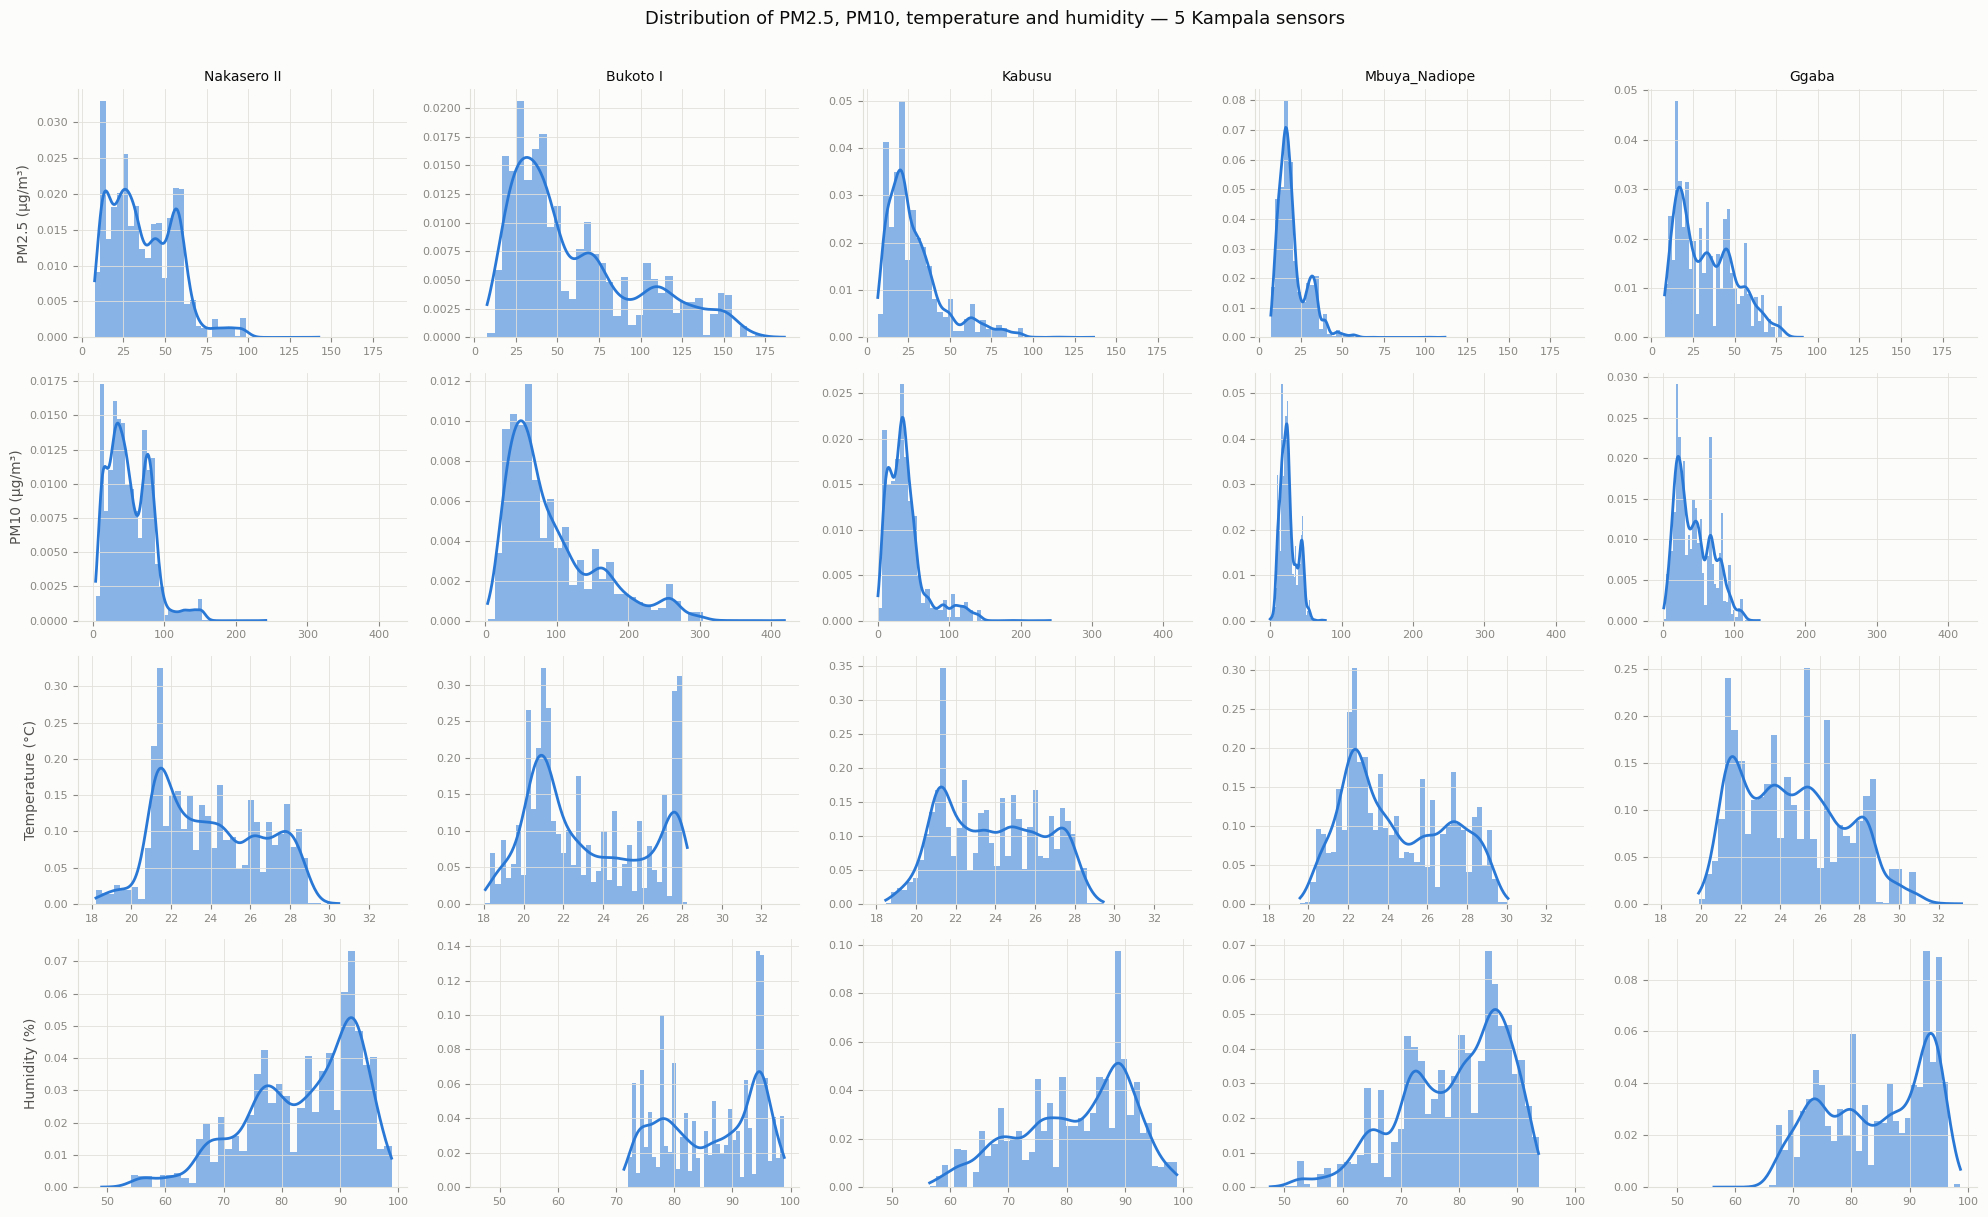

In [39]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde

# Reference palette (light mode) - see dataviz skill, references/palette.md
CHART_SURFACE = '#fcfcfb'
PRIMARY_INK = '#0b0b0b'
SECONDARY_INK = '#52514e'
MUTED_INK = '#898781'
GRIDLINE = '#e1e0d9'
SEQUENTIAL_HUE = '#2a78d6'  # categorical slot 1 / sequential default

plt.rcParams.update({
    'figure.facecolor': CHART_SURFACE,
    'axes.facecolor': CHART_SURFACE,
    'axes.edgecolor': GRIDLINE,
    'axes.labelcolor': SECONDARY_INK,
    'text.color': PRIMARY_INK,
    'xtick.color': MUTED_INK,
    'ytick.color': MUTED_INK,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

field_labels = {
    'pm2_5_calibrated_value': 'PM2.5 (µg/m³)',
    'pm10_calibrated_value': 'PM10 (µg/m³)',
    'temperature': 'Temperature (°C)',
    'humidity': 'Humidity (%)',
}

eda_valid = eda_data[eda_data['datetime'] <= last_observed_timestamp]

fig, axes = plt.subplots(
    len(field_labels), len(eda_site_names),
    figsize=(4 * len(eda_site_names), 3 * len(field_labels)),
    sharex='row',
)

for row, (field, label) in enumerate(field_labels.items()):
    for col, site_name in enumerate(eda_site_names):
        ax = axes[row, col]
        values = eda_valid.loc[eda_valid['site_name'] == site_name, field].dropna()

        ax.hist(values, bins=40, density=True, color=SEQUENTIAL_HUE, alpha=0.55, linewidth=0)
        if values.nunique() > 1:
            kde_x = np.linspace(values.min(), values.max(), 200)
            ax.plot(kde_x, gaussian_kde(values)(kde_x), color=SEQUENTIAL_HUE, linewidth=2)

        if row == 0:
            ax.set_title(site_name.split(',')[0], fontsize=10, color=PRIMARY_INK)
        if col == 0:
            ax.set_ylabel(label, fontsize=10)
        ax.tick_params(labelsize=8)

fig.suptitle('Distribution of PM2.5, PM10, temperature and humidity — 5 Kampala sensors', y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

In [40]:
summary_rows = []
for field, label in field_labels.items():
    for site_name in eda_site_names:
        values = eda_valid.loc[eda_valid['site_name'] == site_name, field].dropna()
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        outlier_share = (
            ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).mean()
        )
        summary_rows.append({
            'field': label,
            'site_name': site_name,
            'mean': values.mean(),
            'std': values.std(),
            'skew': values.skew(),
            'min': values.min(),
            'max': values.max(),
            'iqr_outlier_share': outlier_share,
        })

distribution_summary = pd.DataFrame(summary_rows).round(2)
print("Distribution summary (1.5xIQR rule, informational - full outlier treatment in Step E4); ")
display(distribution_summary)

Distribution summary (1.5xIQR rule, informational - full outlier treatment in Step E4); 


,field,site_name,mean,std,skew,min,max,iqr_outlier_share
0,PM2.5 (µg/m³),"Nakasero II, Kampala 66",36.96,19.25,0.63,7.68,142.44,0.00
1,PM2.5 (µg/m³),"Bukoto I, Kawempe",60.55,38.36,0.91,7.71,186.43,0.01
2,PM2.5 (µg/m³),"Kabusu, Natete Road, Kampala, Uganda",28.61,17.07,1.57,6.69,136.43,0.07
3,PM2.5 (µg/m³),Mbuya_Nadiope,20.05,8.97,1.73,7.08,111.76,0.04
4,PM2.5 (µg/m³),"Ggaba, Makindye",33.10,17.23,0.57,7.91,90.70,0.00
5,PM10 (µg/m³),"Nakasero II, Kampala 66",51.42,29.57,0.86,3.76,241.99,0.01
6,PM10 (µg/m³),"Bukoto I, Kawempe",93.00,63.87,1.24,3.19,418.70,0.05
7,PM10 (µg/m³),"Kabusu, Natete Road, Kampala, Uganda",38.68,27.70,1.76,0.29,241.51,0.08
8,PM10 (µg/m³),Mbuya_Nadiope,25.59,11.39,0.69,0.03,77.26,0.01
9,PM10 (µg/m³),"Ggaba, Makindye",44.47,25.23,0.58,1.76,135.33,0.00
